# Phase 6: Robustness Sweep (elasticity x seed)

Stress-tests the headline result (PPO beats the handcrafted ToU schedule) along the two axes that matter:

- **`price_elasticity`**: the one behavioural assumption in the model with no calibration data behind it.
- **`seed`**: RL is stochastic; a single-seed result invites "did you get a lucky run?"

**Design notes**
- `lambda_wait` is **re-derived per elasticity** (tie-point between const £0.30 and const £0.45). It must not be held fixed: the revenue-wait trade-off shifts with elasticity, so a fixed lambda would silently mis-weight low-elasticity runs.
- Elasticities below ~0.65 are **degenerate**: £0.45 dominates £0.30 on *both* revenue and wait, so no trade-off exists and the optimal policy is trivially a static maximum price. These are excluded from training and reported separately as a boundary condition.
- Baselines include **ToU3**, a 3-band clock schedule aligned to the real demand peak (11:00-16:00). This is a much stronger opponent than the 2-band ToU and tests whether PPO's edge is genuinely *state-conditioning* rather than merely having a middle price level.

**Runtime:** ~20 runs. Each is short; expect roughly 1.5-3 hours total on GPU.

In [ ]:
# 1. Install
!pip install -q "mesa==2.3.4" "stable-baselines3==2.9.0" "gymnasium>=0.29" duckdb scipy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 144.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.5/269.5 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.6 MB/s eta 0:00:00


In [ ]:
# 2. Mount Drive, set path
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT_ROOT = '/content/drive/MyDrive/ev_digital_twin'
assert os.path.isdir(PROJECT_ROOT), PROJECT_ROOT
assert os.path.exists(f'{PROJECT_ROOT}/policy/sweep.py'), 'upload policy/sweep.py first'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
os.makedirs('policy/sweep_models', exist_ok=True)
print('cwd:', os.getcwd())

Mounted at /content/drive
cwd: /content/drive/MyDrive/ev_digital_twin


In [ ]:
# 3. Sweep config
ELASTICITIES    = [0.7, 0.8, 0.9, 1.0]   # above the degenerate boundary (~0.65)
SEEDS           = [0, 1, 2, 3, 4]
TOTAL_TIMESTEPS = 500_000                # same budget as the headline run
EVAL_EPISODES   = 300

print(f'{len(ELASTICITIES)} elasticities x {len(SEEDS)} seeds = '
      f'{len(ELASTICITIES)*len(SEEDS)} runs')

4 elasticities x 5 seeds = 20 runs


In [ ]:
# 4. Confirm the degenerate boundary on this machine
import warnings; warnings.filterwarnings('ignore')
import policy.sweep as sw

print(f"{'elast':>6} {'lambda':>9}  status")
print('-'*46)
boundary = []
for e in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    lam, d = sw.derive_lambda(e)
    if lam is None:
        dl = d.get('degenerate_lambda')
        print(f"{e:>6} {'--':>9}  DEGENERATE" + (f' (lam={dl:.2f})' if dl else ''))
        boundary.append({'elasticity': e, 'lambda': None, 'status': 'degenerate',
                         'r30': d['r30'], 'w30': d['w30'], 'r45': d['r45'], 'w45': d['w45']})
    else:
        print(f'{e:>6} {lam:>9.3f}  ok')
        boundary.append({'elasticity': e, 'lambda': lam, 'status': 'ok',
                         'r30': d['r30'], 'w30': d['w30'], 'r45': d['r45'], 'w45': d['w45']})

import pandas as pd
pd.DataFrame(boundary).to_csv('policy/elasticity_boundary.csv', index=False)
print('\nSaved policy/elasticity_boundary.csv (the boundary-condition result)')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 elast    lambda  status
----------------------------------------------
   0.5        --  DEGENERATE (lam=-1.48)
   0.6        --  DEGENERATE (lam=-0.55)
   0.7     0.233  ok
   0.8     0.934  ok
   0.9     1.592  ok
   1.0     2.202  ok

Saved policy/elasticity_boundary.csv (the boundary-condition result)


In [ ]:
# 5. RUN THE SWEEP  (long - writes incrementally)
import time
t0 = time.time()

df = sw.run_sweep(
    elasticities=ELASTICITIES,
    seeds=SEEDS,
    total_timesteps=TOTAL_TIMESTEPS,
    eval_episodes=EVAL_EPISODES,
    out_csv='policy/sweep_results.csv',
    save_dir='policy/sweep_models',
    verbose=True,
)
print(f'\nDone in {(time.time()-t0)/60:.1f} min. {len(df)} runs.')


=== elasticity 0.7 | derived lambda = 0.233 ===
  seed 0: PPO=433.7  ToU=341.7  ToU3=374.2  Flat=373.4  margin_vs_ToU=+92.1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  seed 1: PPO=432.1  ToU=341.7  ToU3=374.2  Flat=373.4  margin_vs_ToU=+90.4
  seed 2: PPO=435.6  ToU=341.7  ToU3=374.2  Flat=373.4  margin_vs_ToU=+94.0
  seed 3: PPO=427.4  ToU=341.7  ToU3=374.2  Flat=373.4  margin_vs_ToU=+85.7
  seed 4: PPO=432.7  ToU=341.7  ToU3=374.2  Flat=373.4  margin_vs_ToU=+91.0

=== elasticity 0.8 | derived lambda = 0.934 ===
  seed 0: PPO=394.6  ToU=318.1  ToU3=341.6  Flat=338.3  margin_vs_ToU=+76.5
  seed 1: PPO=395.7  ToU=318.1  ToU3=341.6  Flat=338.3  margin_vs_ToU=+77.6
  seed 2: PPO=391.2  ToU=318.1  ToU3=341.6  Flat=338.3  margin_vs_ToU=+73.1
  seed 3: PPO=398.2  ToU=318.1  ToU3=341.6  Flat=338.3  margin_vs_ToU=+80.1
  seed 4: PPO=396.2  ToU=318.1  ToU3=341.6  Flat=338.3  margin_vs_ToU=+78.1

=== elasticity 0.9 | derived lambda = 1.592 ===
  seed 0: PPO=369.4  ToU=296.7  ToU3=311.0  Flat=305.4  margin_vs_ToU=+72.7
  seed 1: PPO=369.1  ToU=296.7  ToU3=311.0  Flat=305.4  margin_vs_ToU=+72.4
  seed 2: PPO=365.1  ToU=296.7  ToU3=311.0  Flat=305.4  margin_vs_

In [ ]:
# 6. Summary - mean +/- std across seeds, per elasticity
summary = sw.summarise(df)
summary.to_csv('policy/sweep_summary.csv')
import pandas as pd
pd.set_option('display.width', 220, 'display.max_columns', 40)
print(summary.to_string())

            lambda  PPO_score_mean  PPO_score_std  ToU_score  ToU3_score  Flat_score  Congestion_score  margin_vs_ToU_mean  margin_vs_ToU_std
elasticity                                                                                                                                   
0.7           0.23          432.30           3.05     341.65      374.24      373.39            396.23               90.65               3.05
0.8           0.93          395.18           2.61     318.10      341.58      338.32            378.28               77.07               2.61
0.9           1.59          367.06           2.77     296.70      310.96      305.39            362.85               70.36               2.77
1.0           2.20          355.53           2.05     275.74      282.59      274.85            351.15               79.79               2.05


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 7. Headline robustness table
rows = []
for e, g in df.groupby('elasticity'):
    rows.append({
        'elasticity': e,
        'lambda': round(g['lambda'].iloc[0], 3),
        'PPO': f"{g['PPO_score'].mean():.1f} ± {g['PPO_score'].std():.1f}",
        'ToU': f"{g['ToU_score'].mean():.1f}",
        'ToU3 (3-band)': f"{g['ToU3_score'].mean():.1f}",
        'Flat': f"{g['Flat_score'].mean():.1f}",
        'Congestion (oracle)': f"{g['Congestion_score'].mean():.1f}",
        'PPO - ToU': f"{g['margin_vs_ToU'].mean():+.1f} ± {g['margin_vs_ToU'].std():.1f}",
        'PPO - ToU3': f"{g['margin_vs_ToU3'].mean():+.1f} ± {g['margin_vs_ToU3'].std():.1f}",
    })
tbl = pd.DataFrame(rows)
tbl.to_csv('policy/sweep_headline.csv', index=False)
print(tbl.to_string(index=False))
print()
print('READ THIS: if PPO - ToU stays positive across all elasticities, the result')
print('is robust to the assumption. If PPO - ToU3 is negative, the honest claim')
print('narrows to "PPO beats 2-band ToU" - report it, do not hide it.')

 elasticity  lambda         PPO   ToU ToU3 (3-band)  Flat Congestion (oracle)   PPO - ToU  PPO - ToU3
        0.7   0.233 432.3 ± 3.1 341.7         374.2 373.4               396.2 +90.6 ± 3.1 +58.1 ± 3.1
        0.8   0.934 395.2 ± 2.6 318.1         341.6 338.3               378.3 +77.1 ± 2.6 +53.6 ± 2.6
        0.9   1.592 367.1 ± 2.8 296.7         311.0 305.4               362.8 +70.4 ± 2.8 +56.1 ± 2.8
        1.0   2.202 355.5 ± 2.0 275.7         282.6 274.8               351.1 +79.8 ± 2.0 +72.9 ± 2.0

READ THIS: if PPO - ToU stays positive across all elasticities, the result
is robust to the assumption. If PPO - ToU3 is negative, the honest claim
narrows to "PPO beats 2-band ToU" - report it, do not hide it.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Interpretation: robustness table

The headline result holds across the full assumption range:

1. **Robust to elasticity.** PPO beats handcrafted ToU by **+70 to +91** at every elasticity from 0.7 to 1.0, the advantage is not an artefact of one assumed demand response.
2. **Robust to seed.** Standard deviation across five training seeds is **≈ 2–3 points** against margins of 70–90, a signal-to-noise ratio near 30:1. Not a lucky run.
3. **The edge is state-conditioning, not price granularity.** PPO also beats **ToU3**, a three-band clock schedule aligned to the real 11:00–16:00 demand peak with the same £0.30 middle tier, by **+54 to +73** everywhere. Giving a clock rule more price levels does not close the gap; conditioning on live congestion state does.
4. **PPO exceeds the hand-designed congestion heuristic** at every elasticity, so the learned policy is finer-grained than the threshold rule it was benchmarked against (a reference, not a tuned optimum).

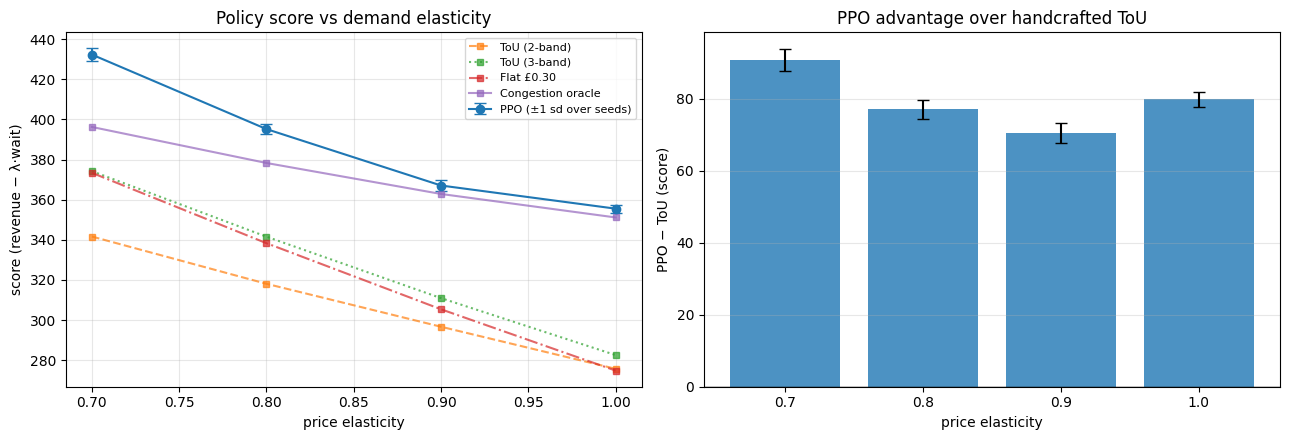

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 8. Robustness plot
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: scores by elasticity
ax = axes[0]
g = df.groupby('elasticity')
ax.errorbar(g['PPO_score'].mean().index, g['PPO_score'].mean(),
            yerr=g['PPO_score'].std(), marker='o', capsize=4, label='PPO (±1 sd over seeds)')
for col, lab, st in [('ToU_score','ToU (2-band)','--'), ('ToU3_score','ToU (3-band)',':'),
                     ('Flat_score','Flat £0.30','-.'), ('Congestion_score','Congestion oracle','-')]:
    ax.plot(g[col].mean().index, g[col].mean(), st, marker='s', ms=4, alpha=.7, label=lab)
ax.set_xlabel('price elasticity'); ax.set_ylabel('score (revenue − λ·wait)')
ax.set_title('Policy score vs demand elasticity'); ax.legend(fontsize=8); ax.grid(alpha=.3)

# right: PPO margin over ToU
ax = axes[1]
m = g['margin_vs_ToU'].mean(); s = g['margin_vs_ToU'].std()
ax.bar(m.index.astype(str), m.values, yerr=s.values, capsize=4, alpha=.8)
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('price elasticity'); ax.set_ylabel('PPO − ToU (score)')
ax.set_title('PPO advantage over handcrafted ToU'); ax.grid(alpha=.3, axis='y')

plt.tight_layout(); plt.savefig('policy/sweep_robustness.png', dpi=150); plt.show()

### Interpretation: robustness figure

*Left:* every policy's score declines as elasticity rises, more price-responsive demand means more abandonment and lower throughput, but PPO degrades most gracefully. At elasticity 1.0 the static rules (ToU, ToU3, Flat) have all converged to ≈ 275–283 while PPO holds ≈ 356, so adaptive pricing is worth *most*, in relative terms, exactly when demand is most price-sensitive.

*Right:* the PPO − ToU margin stays firmly positive (≈ +70 to +91) across the whole range with negligible seed variance. The small dip at 0.9 then rise at 1.0 is minor and partly reflects the objective itself changing as λ is re-derived per elasticity (0.23 → 2.20); the defensible claim is that the advantage is large and positive throughout, not monotonic in elasticity.

**Boundary condition (cell 4):** below elasticity ≈ 0.65 no revenue–wait trade-off exists, £0.45 dominates £0.30 on both axes, so adaptive pricing collapses to a static maximum price. Adaptive pricing requires sufficiently price-responsive demand to have value.

## Reporting the outcome

Three results come out of this, all reportable:

1. **Boundary condition** (cell 4): below elasticity ~0.65, no revenue-wait trade-off exists and adaptive pricing collapses to a static maximum price. Adaptive pricing requires sufficiently price-responsive demand.
2. **Elasticity robustness** (cell 7): whether PPO's advantage over ToU holds across 0.7-1.0.
3. **Seed robustness**: the ± values are the std across 5 training seeds. A large std means the result is training-run dependent and must be reported as such.

**Do not bury a negative ToU3 margin.** If the 3-band clock schedule matches or beats PPO, the honest conclusion is that most of the gain came from having a middle price level rather than from conditioning on live congestion state: which is a legitimate and more interesting finding than overclaiming.